**Model:** Simple Neural Network (MLP)  
**Attack 1:** Membership Inference Attack  
**Attack 2:** Poisoning Attack (Label Flipping)

## Download Dataset via Kaggle API

Go to https://www.kaggle.com/settings → API → Create New Token  
Place the `.json` file at `C:\Users\yourusername\.kaggle\kaggle.json`

---

## 1. Download Dataset

In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(f"Dataset downloaded to: {path}")

# Find the CSV file inside the downloaded folder
csv_file = None
for f in os.listdir(path):
    if f.endswith('.csv'):
        csv_file = os.path.join(path, f)
        break

print(f"CSV path: {csv_file}")

c:\Users\BlueberryPancake\miniconda3\envs\DL\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\BlueberryPancake\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1
CSV path: C:\Users\BlueberryPancake\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1\IMDB Dataset.csv


## 2. Load & Explore Data

In [2]:
import pandas as pd

df = pd.read_csv(csv_file)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['sentiment'].value_counts())
df.head(3)

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 3. Text Preprocessing

In [3]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)     # remove special chars and numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess)

# Before / after example
print("Before:")
print(df['review'].iloc[0][:300])
print("\nAfter:")
print(df['clean_review'].iloc[0][:300])

Before:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

After:
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximu


## 4. Encode Labels & Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

# Encode labels: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 40000
Test size:  10000


## 5. TF-IDF Vectorization

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
# Fitted only on the training set to avoid data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

Feature matrix shape: (40000, 20000)


## 6. Build & Train the Model

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Convert sparse TF-IDF matrices to dense arrays
X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_test_dense  = X_test_tfidf.toarray().astype(np.float32)
y_train_arr   = y_train.values.astype(np.float32)
y_test_arr    = y_test.values.astype(np.float32)

input_dim = X_train_dense.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train_dense, y_train_arr,
    epochs=30,          
    batch_size=256,
    validation_split=0.1,
    verbose=1
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               5120256   
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5,136,769
Trainable params: 5,136,769
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
141/141 [==============================] - 7s 45ms/step - loss: 0.3330 - accuracy: 0.8731 - val_loss: 0.2553 - val_accuracy: 0.8940
Epoch 2/30
141/141 [==============================] - 6s 42ms/step - loss: 0.1374 - accuracy: 0.9534 - val_loss: 0.2963 - val_accuracy: 0.8835
Epoch 3/30
141/141 [====

## 7. Baseline Evaluation

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

probs  = model.predict(X_test_dense, verbose=0).flatten()
y_pred = (probs >= 0.5).astype(int)

accuracy  = accuracy_score(y_test_arr, y_pred)
precision = precision_score(y_test_arr, y_pred)
recall    = recall_score(y_test_arr, y_pred)
f1        = f1_score(y_test_arr, y_pred)

print("BASELINE PERFORMANCE")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")
print()
print(classification_report(y_test_arr, y_pred, target_names=['Negative', 'Positive']))

BASELINE PERFORMANCE
  Accuracy : 0.8778
  Precision: 0.8790
  Recall   : 0.8762
  F1-Score : 0.8776

              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      5000
    Positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## 8. Save Artifacts

In [8]:
# import joblib

# # Save model (architecture + weights)
# model.save('model.h5')

# # Save the vectorizer
# joblib.dump(vectorizer, 'vectorizer.pkl')

# # Save all splits so every team member uses the exact same data
# X_train.to_csv('X_train.csv', index=False)
# X_test.to_csv('X_test.csv',  index=False)
# y_train.to_csv('y_train.csv', index=False)
# y_test.to_csv('y_test.csv',  index=False)

# print("Saved: model.h5, vectorizer.pkl, X_train.csv, X_test.csv, y_train.csv, y_test.csv")

---
# Membership Inference Attack (ART)

**Concept:**  
A membership inference attack tries to determine whether a given sample was part of the model's training set.  

The gap in the model makes it a clear target:
- Train accuracy: ~99.8%  
- Test accuracy:  ~87.8%

**How the attack works (ART `MembershipInferenceBlackBox`):**  
ART wraps the target model and trains an internal attack model that learns to distinguish members from non-members based on the target model's output probabilities. We only need to provide it with some known members (train samples) and non-members (test samples) to fit on.

### Step 0 — Install ART

In [9]:
# !pip install adversarial-robustness-toolbox --quiet

### Step 1 — Wrap the Model with ART

In [10]:
from art.estimators.classification import TensorFlowV2Classifier
import tensorflow as tf


loss_fn = tf.keras.losses.BinaryCrossentropy()

art_classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=2,
    input_shape=(X_train_dense.shape[1],),
    loss_object=loss_fn,
    clip_values=(0.0, 1.0)
)

print("Model wrapped with ART TensorFlowV2Classifier.")

c:\Users\BlueberryPancake\miniconda3\envs\DL\lib\site-packages\art\estimators\certification\__init__.py:30: UserWarning: PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality
  warnings.warn("PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality")


Model wrapped with ART TensorFlowV2Classifier.


### Step 2 — Set Up the Attack

In [11]:
from art.attacks.inference.membership_inference import MembershipInferenceBlackBox

# Use a subset of train/test to keep things fast
# attack_train_size  — samples used to *fit* the attack model (must be members + non-members)
# attack_test_size   — samples used to *evaluate* the attack
attack_train_size = 2000
attack_test_size  = 2000

# Members: samples the target model was trained on
member_train = X_train_dense[:attack_train_size]
member_test  = X_train_dense[attack_train_size:attack_train_size + attack_test_size]

# Non-members: samples the target model has never seen
nonmember_train = X_test_dense[:attack_train_size]
nonmember_test  = X_test_dense[attack_train_size:attack_train_size + attack_test_size]


# NEURAL NET USES TORCH, using random forest instead
attack = MembershipInferenceBlackBox(art_classifier, attack_model_type='rf')


### Step 3 — Fit the Attack

In [12]:
# Fit the attack model on known members and non-members
attack.fit(
    member_train,
    y_train_arr[:attack_train_size],
    nonmember_train,
    y_test_arr[:attack_train_size]
)

print("Attack model fitted.")

Attack model fitted.


### Step 4 — Run Inference & Evaluate

In [13]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# infer() returns 1 (member) or 0 (non-member) for each sample
member_preds    = attack.infer(member_test,    y_train_arr[attack_train_size:attack_train_size + attack_test_size])
nonmember_preds = attack.infer(nonmember_test, y_test_arr[attack_train_size:attack_train_size + attack_test_size])

# Ground truth: members=1, non-members=0
y_true = np.concatenate([np.ones(attack_test_size), np.zeros(attack_test_size)])
y_pred_atk = np.concatenate([member_preds, nonmember_preds])

atk_acc = accuracy_score(y_true, y_pred_atk)

print("MEMBERSHIP INFERENCE ATTACK RESULTS")
print(f"  Attack Accuracy : {atk_acc:.4f}")
print()
print("  > Baseline (random guessing) : 0.5000")
print(f"  > the attack        : {atk_acc:.4f}")
print()
print(classification_report(y_true, y_pred_atk, target_names=['Non-member', 'Member']))

MEMBERSHIP INFERENCE ATTACK RESULTS
  Attack Accuracy : 0.6095

  > Baseline (random guessing) : 0.5000
  > the attack        : 0.6095

              precision    recall  f1-score   support

  Non-member       0.89      0.25      0.39      2000
      Member       0.56      0.97      0.71      2000

    accuracy                           0.61      4000
   macro avg       0.73      0.61      0.55      4000
weighted avg       0.73      0.61      0.55      4000



### Step 5 — Visualize the Confidence Gap

In [14]:
# import matplotlib.pyplot as plt

# # Get raw confidence scores to visualize what the attack exploits
# train_probs = model.predict(X_train_dense, verbose=0).flatten()
# test_probs  = model.predict(X_test_dense,  verbose=0).flatten()

# train_confidence = np.maximum(train_probs, 1 - train_probs)
# test_confidence  = np.maximum(test_probs,  1 - test_probs)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# # Histogram: confidence distributions
# axes[0].hist(train_confidence, bins=50, alpha=0.6, label='Members (train)', color='steelblue')
# axes[0].hist(test_confidence,  bins=50, alpha=0.6, label='Non-members (test)', color='tomato')
# axes[0].set_title('Confidence Score Distribution')
# axes[0].set_xlabel('Model Confidence')
# axes[0].set_ylabel('Count')
# axes[0].legend()

# # Box plot
# axes[1].boxplot(
#     [train_confidence, test_confidence],
#     labels=['Members\n(train)', 'Non-members\n(test)'],
#     patch_artist=True,
#     boxprops=dict(facecolor='steelblue', alpha=0.6)
# )
# axes[1].set_title('Confidence Score Comparison')
# axes[1].set_ylabel('Model Confidence')

# plt.suptitle('Membership Inference Attack — Confidence Gap', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig('membership_inference_attack.png', dpi=150)
# plt.show()

# print(f"Avg confidence on TRAIN samples : {train_confidence.mean():.4f}")
# print(f"Avg confidence on TEST  samples : {test_confidence.mean():.4f}")

---
# Poisoning Attack

**Concept:**  
A poisoning attack corrupts the training data before the model is trained.


### Step 1 — Poison the Training Data

In [15]:
import numpy as np

POISON_RATE = 0.3   # fraction of training samples to flip (30%)

np.random.seed(42)
n_train = len(y_train_arr)
n_poison = int(POISON_RATE * n_train)

# Randomly select indices to poison
poison_indices = np.random.choice(n_train, size=n_poison, replace=False)

# Copy labels and flip selected ones
y_train_poisoned = y_train_arr.copy()
y_train_poisoned[poison_indices] = 1 - y_train_poisoned[poison_indices]

n_flipped = (y_train_poisoned != y_train_arr).sum()
print(f"Total training samples : {n_train}")
print(f"Poison rate            : {POISON_RATE*100:.0f}%")
print(f"Labels flipped         : {n_flipped}")

Total training samples : 40000
Poison rate            : 30%
Labels flipped         : 12000


### Step 2 — Retrain on Poisoned Data

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

# Same architecture as the clean model
poisoned_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

poisoned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

poisoned_model.fit(
    X_train_dense, y_train_poisoned,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)


Epoch 1/30
141/141 [==============================] - 6s 43ms/step - loss: 0.6569 - accuracy: 0.6282 - val_loss: 0.6490 - val_accuracy: 0.6317
Epoch 2/30
141/141 [==============================] - 6s 40ms/step - loss: 0.5534 - accuracy: 0.7244 - val_loss: 0.7038 - val_accuracy: 0.6105
Epoch 3/30
141/141 [==============================] - 5s 39ms/step - loss: 0.3651 - accuracy: 0.8452 - val_loss: 0.9033 - val_accuracy: 0.5893
Epoch 4/30
141/141 [==============================] - 5s 38ms/step - loss: 0.1036 - accuracy: 0.9703 - val_loss: 1.3527 - val_accuracy: 0.5623
Epoch 5/30
141/141 [==============================] - 6s 39ms/step - loss: 0.0194 - accuracy: 0.9952 - val_loss: 1.7465 - val_accuracy: 0.5727
Epoch 6/30
141/141 [==============================] - 6s 39ms/step - loss: 0.0104 - accuracy: 0.9965 - val_loss: 1.9952 - val_accuracy: 0.5648
Epoch 7/30
141/141 [==============================] - 5s 38ms/step - loss: 0.0078 - accuracy: 0.9968 - val_loss: 2.1579 - val_accuracy: 0.5680

### Step 3 — Evaluate & Compare

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate poisoned model on the same clean test set
probs_poisoned  = poisoned_model.predict(X_test_dense, verbose=0).flatten()
y_pred_poisoned = (probs_poisoned >= 0.5).astype(int)

acc_clean    = accuracy_score(y_test_arr, y_pred)           # from baseline cell
acc_poisoned = accuracy_score(y_test_arr, y_pred_poisoned)

print("POISONING ATTACK RESULTS")
print(f"  {'Metric':<12} {'Clean Model':>12} {'Poisoned Model':>15}")
print(f"  {'-'*40}")
print(f"  {'Accuracy':<12} {accuracy_score(y_test_arr, y_pred):>12.4f} {accuracy_score(y_test_arr, y_pred_poisoned):>15.4f}")
print(f"  {'Precision':<12} {precision_score(y_test_arr, y_pred):>12.4f} {precision_score(y_test_arr, y_pred_poisoned):>15.4f}")
print(f"  {'Recall':<12} {recall_score(y_test_arr, y_pred):>12.4f} {recall_score(y_test_arr, y_pred_poisoned):>15.4f}")
print(f"  {'F1-Score':<12} {f1_score(y_test_arr, y_pred):>12.4f} {f1_score(y_test_arr, y_pred_poisoned):>15.4f}")
print(f"\n  Accuracy drop: {acc_clean - acc_poisoned:.4f} ({(acc_clean - acc_poisoned)*100:.1f} percentage points)")
print()
print("Poisoned model — classification report:")
print(classification_report(y_test_arr, y_pred_poisoned, target_names=['Negative', 'Positive']))

POISONING ATTACK RESULTS
  Metric        Clean Model  Poisoned Model
  ----------------------------------------
  Accuracy           0.8778          0.6860
  Precision          0.8790          0.6934
  Recall             0.8762          0.6668
  F1-Score           0.8776          0.6799

  Accuracy drop: 0.1918 (19.2 percentage points)

Poisoned model — classification report:
              precision    recall  f1-score   support

    Negative       0.68      0.71      0.69      5000
    Positive       0.69      0.67      0.68      5000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



### Step 4 — Visualize the Impact

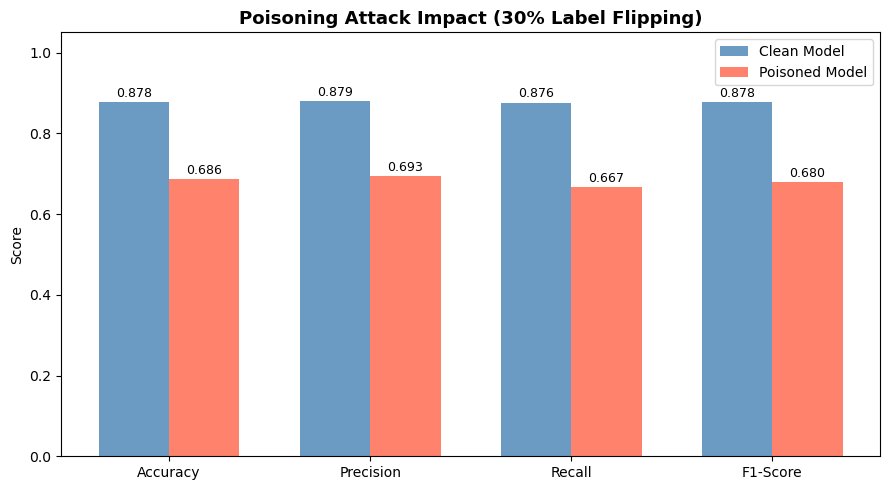

In [18]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
clean_scores    = [
    accuracy_score(y_test_arr, y_pred),
    precision_score(y_test_arr, y_pred),
    recall_score(y_test_arr, y_pred),
    f1_score(y_test_arr, y_pred)
]
poisoned_scores = [
    accuracy_score(y_test_arr, y_pred_poisoned),
    precision_score(y_test_arr, y_pred_poisoned),
    recall_score(y_test_arr, y_pred_poisoned),
    f1_score(y_test_arr, y_pred_poisoned)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, clean_scores,    width, label='Clean Model',    color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, poisoned_scores, width, label='Poisoned Model', color='tomato',    alpha=0.8)

# Add value labels on bars
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title(f'Poisoning Attack Impact ({int(POISON_RATE*100)}% Label Flipping)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig('poisoning_attack.png', dpi=150)
plt.show()

---
# DEFENSES

DEFENSE 1: Data Filtering

In [21]:
from sklearn.linear_model import LogisticRegression

print("\n================ DEFENSES =================")

# Train a simple reference model to detect suspicious samples
ref_model = LogisticRegression(max_iter=1000)
ref_model.fit(X_train_dense, y_train_arr)

# Get model predictions on training data
preds = ref_model.predict(X_train_dense)

# Get prediction confidence (how sure the model is)
conf = np.max(ref_model.predict_proba(X_train_dense), axis=1)

# Keep only samples that are correctly classified with high confidence
# This helps remove noisy / poisoned data points
mask = (preds == y_train_arr) & (conf > 0.6)

# Filter out suspicious samples
X_clean = X_train_dense[mask]
y_clean = y_train_arr[mask]

# Show how many samples were removed
print("Removed samples:", len(X_train_dense) - len(X_clean))


================ DEFENSES =================
Removed samples: 4949


DEFENSE 2: Clipping + Noise

In [24]:
# ======================= DEFENSE MODEL ==========================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
def get_metrics(model, X, y):
    # Get model predictions as probabilities
    probs = model.predict(X, verbose=0).ravel()
    
    # Convert probabilities into binary predictions
    preds = (probs >= 0.5).astype(int)
    
    # Compute evaluation metrics
    return {
        "accuracy": accuracy_score(y, preds),
        "f1": f1_score(y, preds),
        "auc": roc_auc_score(y, probs),
        "probs": probs
    }

# Create a fresh model based on original architecture
defense_model = keras.models.clone_model(model)

# Compile the model
defense_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model on cleaned (filtered) dataset
defense_model.fit(X_clean, y_clean, epochs=5, verbose=0)

# Evaluate normal model performance after defense
def_metrics = get_metrics(defense_model, X_test_dense, y_test_arr)

In [27]:
def clip_probs(p):
    # Limit probabilities to reduce overconfident predictions (privacy defense)
    return np.clip(p, 0.3, 0.7)

def add_noise(p):
    # Add small random noise to predictions to reduce membership inference signal
    return np.clip(p + np.random.normal(0, 0.05, p.shape), 0, 1)

# =================== MIA DEFENSE (NOISE + CLIP) ================
# Get prediction probabilities for train/test data
train_probs_def = defense_model.predict(X_clean).ravel()
test_probs_def  = defense_model.predict(X_test_dense).ravel()

# Apply probability clipping + noise to reduce overconfidence
train_probs_def = add_noise(clip_probs(train_probs_def))
test_probs_def  = add_noise(clip_probs(test_probs_def))

# Build dataset for membership inference attack evaluation
X_atk = np.concatenate([train_probs_def, test_probs_def])
y_atk = np.concatenate([np.ones(len(train_probs_def)), np.zeros(len(test_probs_def))])

# Train simple attack model (logistic regression)
atk_model = LogisticRegression().fit(X_atk.reshape(-1, 1), y_atk)

# Get attack probabilities
atk_probs = atk_model.predict_proba(X_atk.reshape(-1, 1))[:, 1]

# Measure privacy leakage after defense
mia_auc_def = roc_auc_score(y_atk, atk_probs)



313/313 [==============================] - 1s 4ms/step


In [30]:
# ======================== RESULTS ===============================
print("Defended Accuracy:", def_metrics["accuracy"])
print("MIA AUC (Defended):", mia_auc_def)

Defended Accuracy: 0.8843
MIA AUC (Defended): 0.5001518244843228


---
# FINAL COMPARISON

In [33]:
print("\n================ FINAL COMPARISON =================")

base_acc = accuracy_score(y_test_arr, y_pred)
print(f"Before Attack  → Acc: {base_acc:.4f}")
print(f"After Attack   → Acc: {accuracy_score(y_test_arr, y_pred_poisoned):.4f}")
print(f"After Defense  → Acc: {def_metrics['accuracy']:.4f}")

mia_auc_base = roc_auc_score(y_true, y_pred_atk)
print(f"\nMIA AUC Before Defense : {mia_auc_base:.4f}")
print(f"MIA AUC After Defense  : {mia_auc_def:.4f}")


================ FINAL COMPARISON =================
Before Attack  → Acc: 0.8778
After Attack   → Acc: 0.6860
After Defense  → Acc: 0.8843

MIA AUC Before Defense : 0.6095
MIA AUC After Defense  : 0.5002


---
# PLOTS

In [34]:
def plot_confidence(train_probs, test_probs, title):
    # Plot distribution of prediction confidence for train vs test data
    plt.figure()
    
    plt.hist(train_probs, bins=50, alpha=0.5, label="Train")
    plt.hist(test_probs, bins=50, alpha=0.5, label="Test")
    
    plt.title(title)
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


def plot_accuracy(base, poison, defense):
    # Compare model accuracy before attack, after poisoning, and after defense
    plt.figure()
    
    plt.bar(["Base", "Poisoned", "Defended"], [base, poison, defense])
    
    plt.title("Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.show()


def plot_mia_auc(base, poison, defense):
    # Compare privacy leakage (MIA AUC) across different model states
    plt.figure()
    
    plt.bar(["Base", "Poisoned", "Defended"], [base, poison, defense])
    
    plt.title("MIA AUC Comparison (Privacy Leakage)")
    plt.ylabel("AUC")
    plt.show()

313/313 [==============================] - 1s 4ms/step


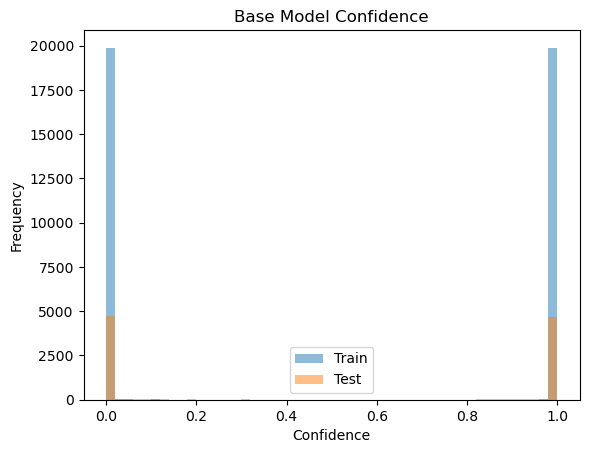

313/313 [==============================] - 1s 4ms/step


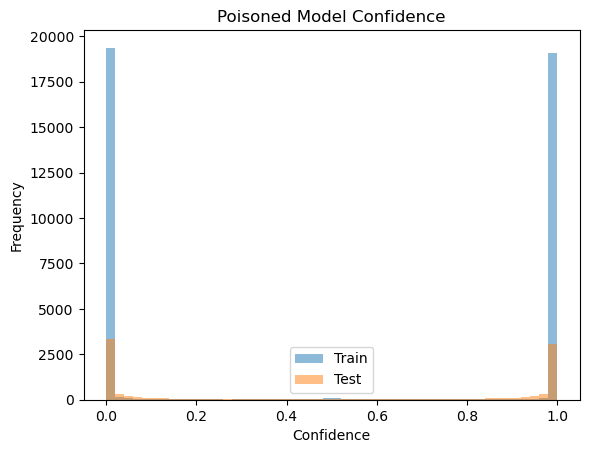

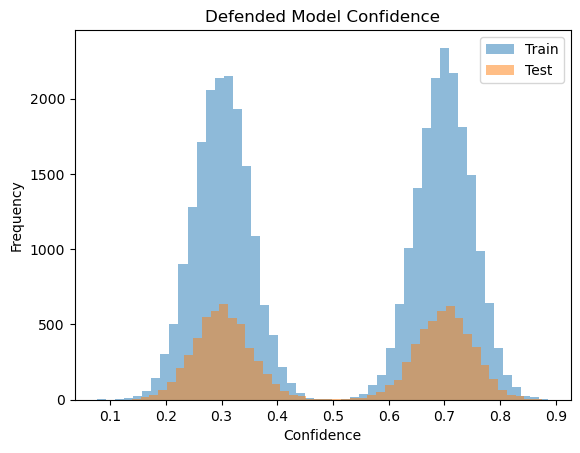

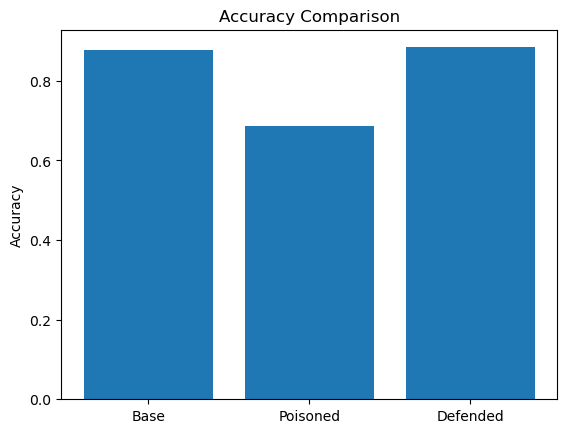

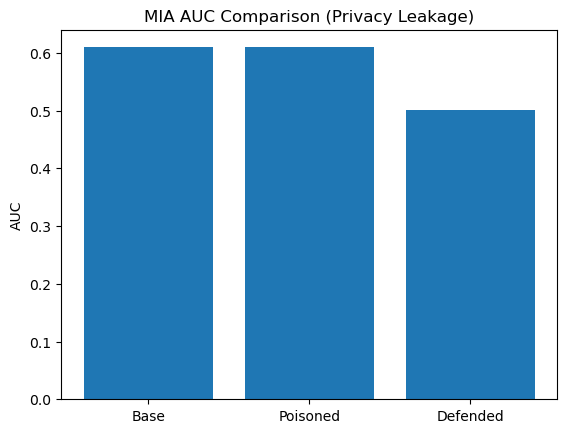

In [37]:
plot_confidence(
    model.predict(X_train_dense).ravel(),
    model.predict(X_test_dense).ravel(),
    "Base Model Confidence"
)

plot_confidence(
    poisoned_model.predict(X_train_dense).ravel(),
    poisoned_model.predict(X_test_dense).ravel(),
    "Poisoned Model Confidence"
)

plot_confidence(
    train_probs_def,
    test_probs_def,
    "Defended Model Confidence"
)

plot_accuracy(
    accuracy_score(y_test_arr, y_pred),              
    accuracy_score(y_test_arr, y_pred_poisoned),     
    def_metrics["accuracy"]
)

plot_mia_auc(
    mia_auc_base,
    mia_auc_base,
    mia_auc_def
)